AYNA KHAN (24I-0097)

DUR E ADAN (24I-3037)

AI (4-C)

PROBABILITY & STATISTICS FINAL PROJECT



---



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

In [7]:
print(df.columns)

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

### Correlation Analysis

Let's calculate the correlation matrix for all numerical features and visualize it using a heatmap. This will help us understand the relationships between variables, especially with the target variable `shares`, and identify any highly correlated (potentially redundant) features.

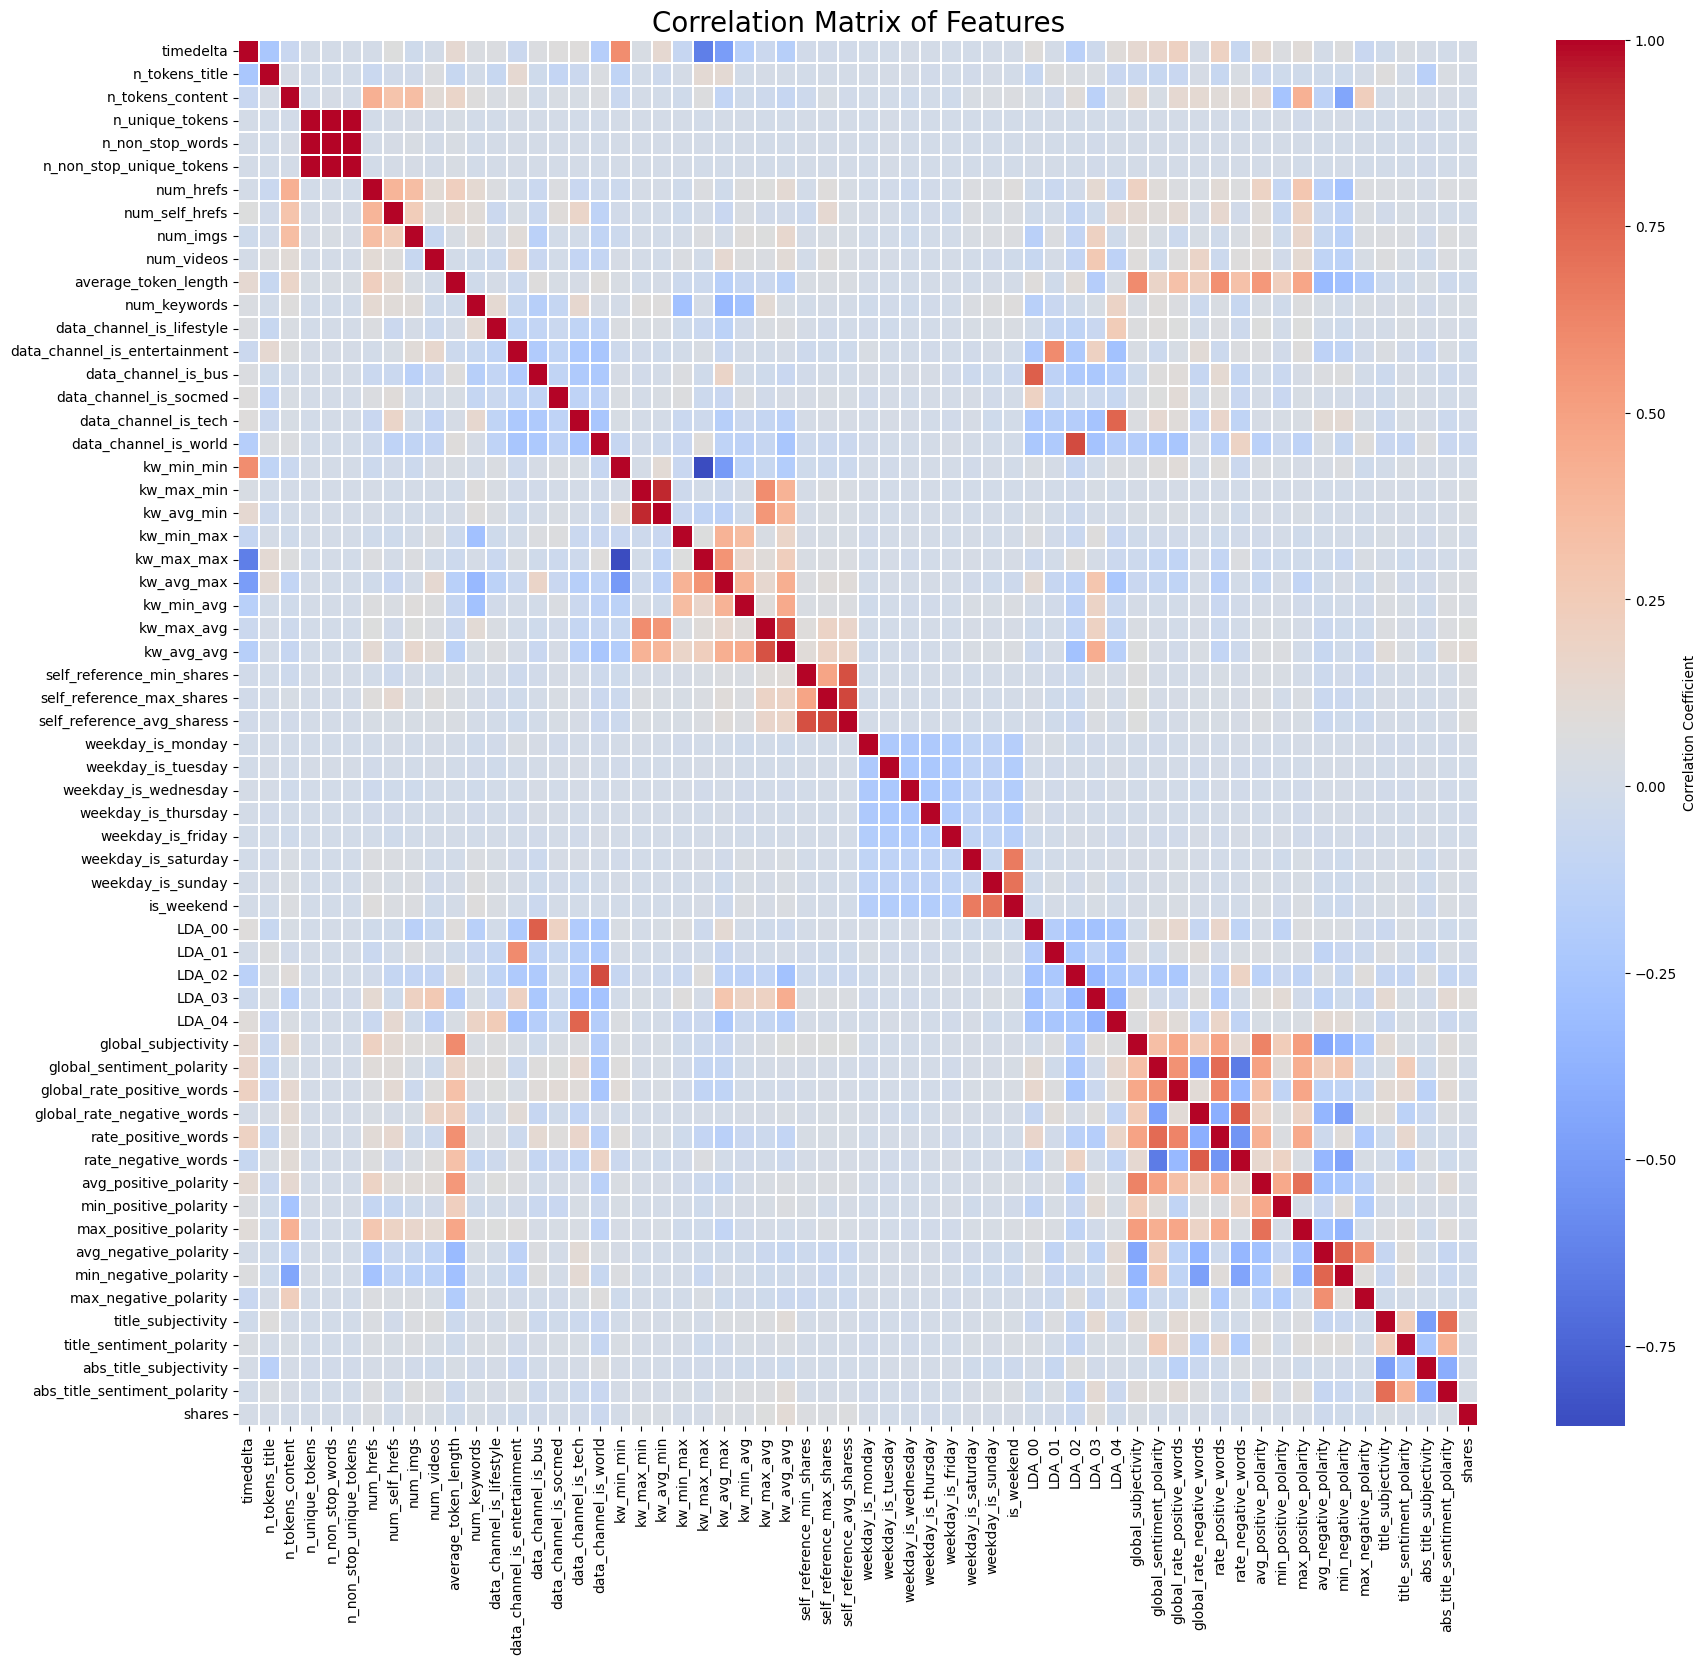

In [9]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=.05, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Features', fontsize=20)
plt.show()

### Target Variable Analysis: 'shares'

Let's analyze the distribution of our target variable, 'shares'. Understanding its spread and identifying potential outliers is crucial before proceeding with model building, as extreme values can heavily influence linear regression models.

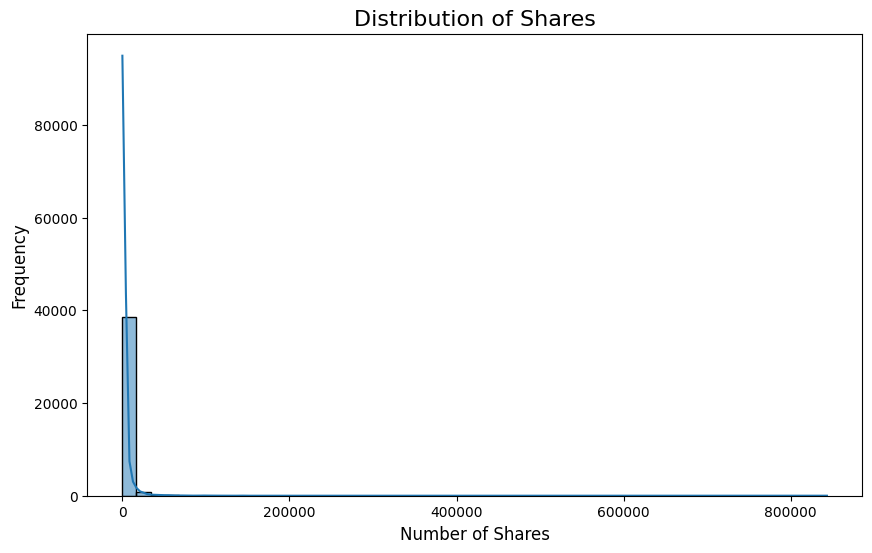

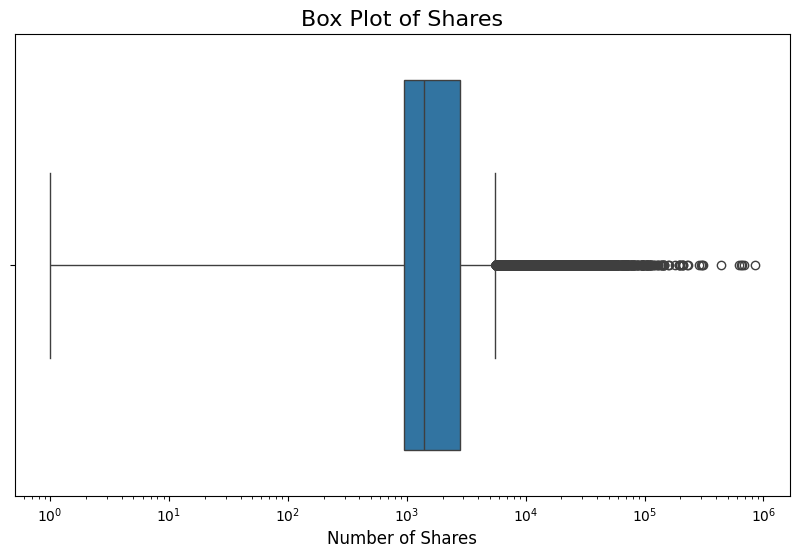

,shares
count,39644.000000
mean,3395.380184
std,11626.950749
min,1.000000
25%,946.000000
50%,1400.000000
75%,2800.000000
max,843300.000000


Number of articles with more than 50,000 shares: 203
Number of articles with more than 100,000 shares: 58
Number of articles with more than 500,000 shares: 5


In [12]:
# Plot the distribution of 'shares'
plt.figure(figsize=(10, 6))
sns.histplot(df['shares'], bins=50, kde=True)
plt.title('Distribution of Shares', fontsize=16)
plt.xlabel('Number of Shares', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Plot a box plot to visualize outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['shares'])
plt.title('Box Plot of Shares', fontsize=16)
plt.xlabel('Number of Shares', fontsize=12)
plt.xscale('log') #we are using log scale for better visualization of skewed data
plt.show()

# Display descriptive statistics for 'shares'
display(df['shares'].describe())

# Check for articles with extremely high shares (potential outliers)
print(f"Number of articles with more than 50,000 shares: {(df['shares'] > 50000).sum()}")
print(f"Number of articles with more than 100,000 shares: {(df['shares'] > 100000).sum()}")
print(f"Number of articles with more than 500,000 shares: {(df['shares'] > 500000).sum()}")

### Log Transformation of 'shares'

Since the 'shares' variable is highly skewed, we will apply a log transformation to normalize its distribution. This often improves model performance by making the data conform more closely to the assumptions of linear regression. We'll add 1 before taking the logarithm to handle any potential zero values gracefully (though the minimum 'shares' value is 1, so this primarily addresses the shift).


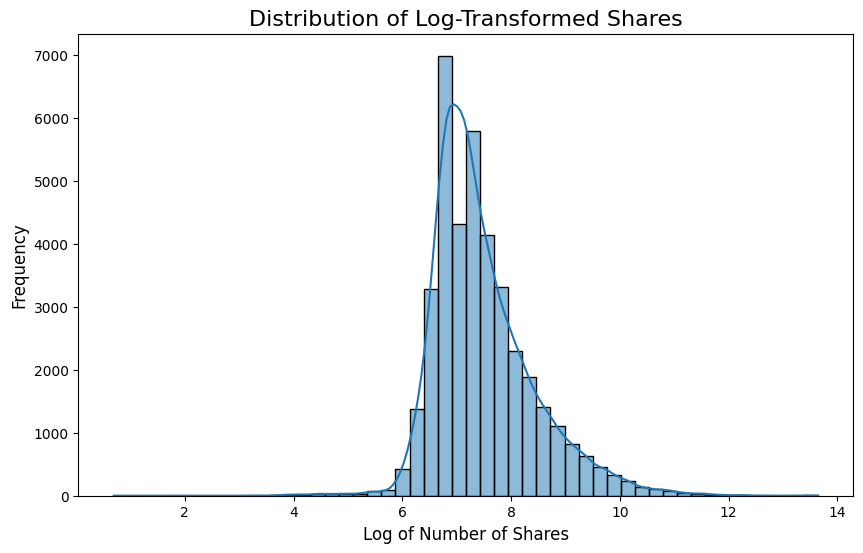

,shares_log
count,39644.000000
mean,7.475692
std,0.929674
min,0.693147
25%,6.853299
50%,7.244942
75%,7.937732
max,13.645079


In [15]:
df.columns = df.columns.str.strip()
# Apply log transformation to 'shares' (adding 1 to handle potential zero values, though min is 1 here)
df['shares_log'] = np.log(df['shares'] + 1)

# Plot the distribution of the log-transformed 'shares'
plt.figure(figsize=(10, 6))
sns.histplot(df['shares_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Shares', fontsize=16)
plt.xlabel('Log of Number of Shares', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Display descriptive statistics for 'shares_log'
display(df['shares_log'].describe())

### Correlation Analysis

Let's calculate the correlation matrix for all numerical features and visualize it using a heatmap. This will help us understand the relationships between variables, especially with the target variable `shares`, and identify any highly correlated (potentially redundant) features.

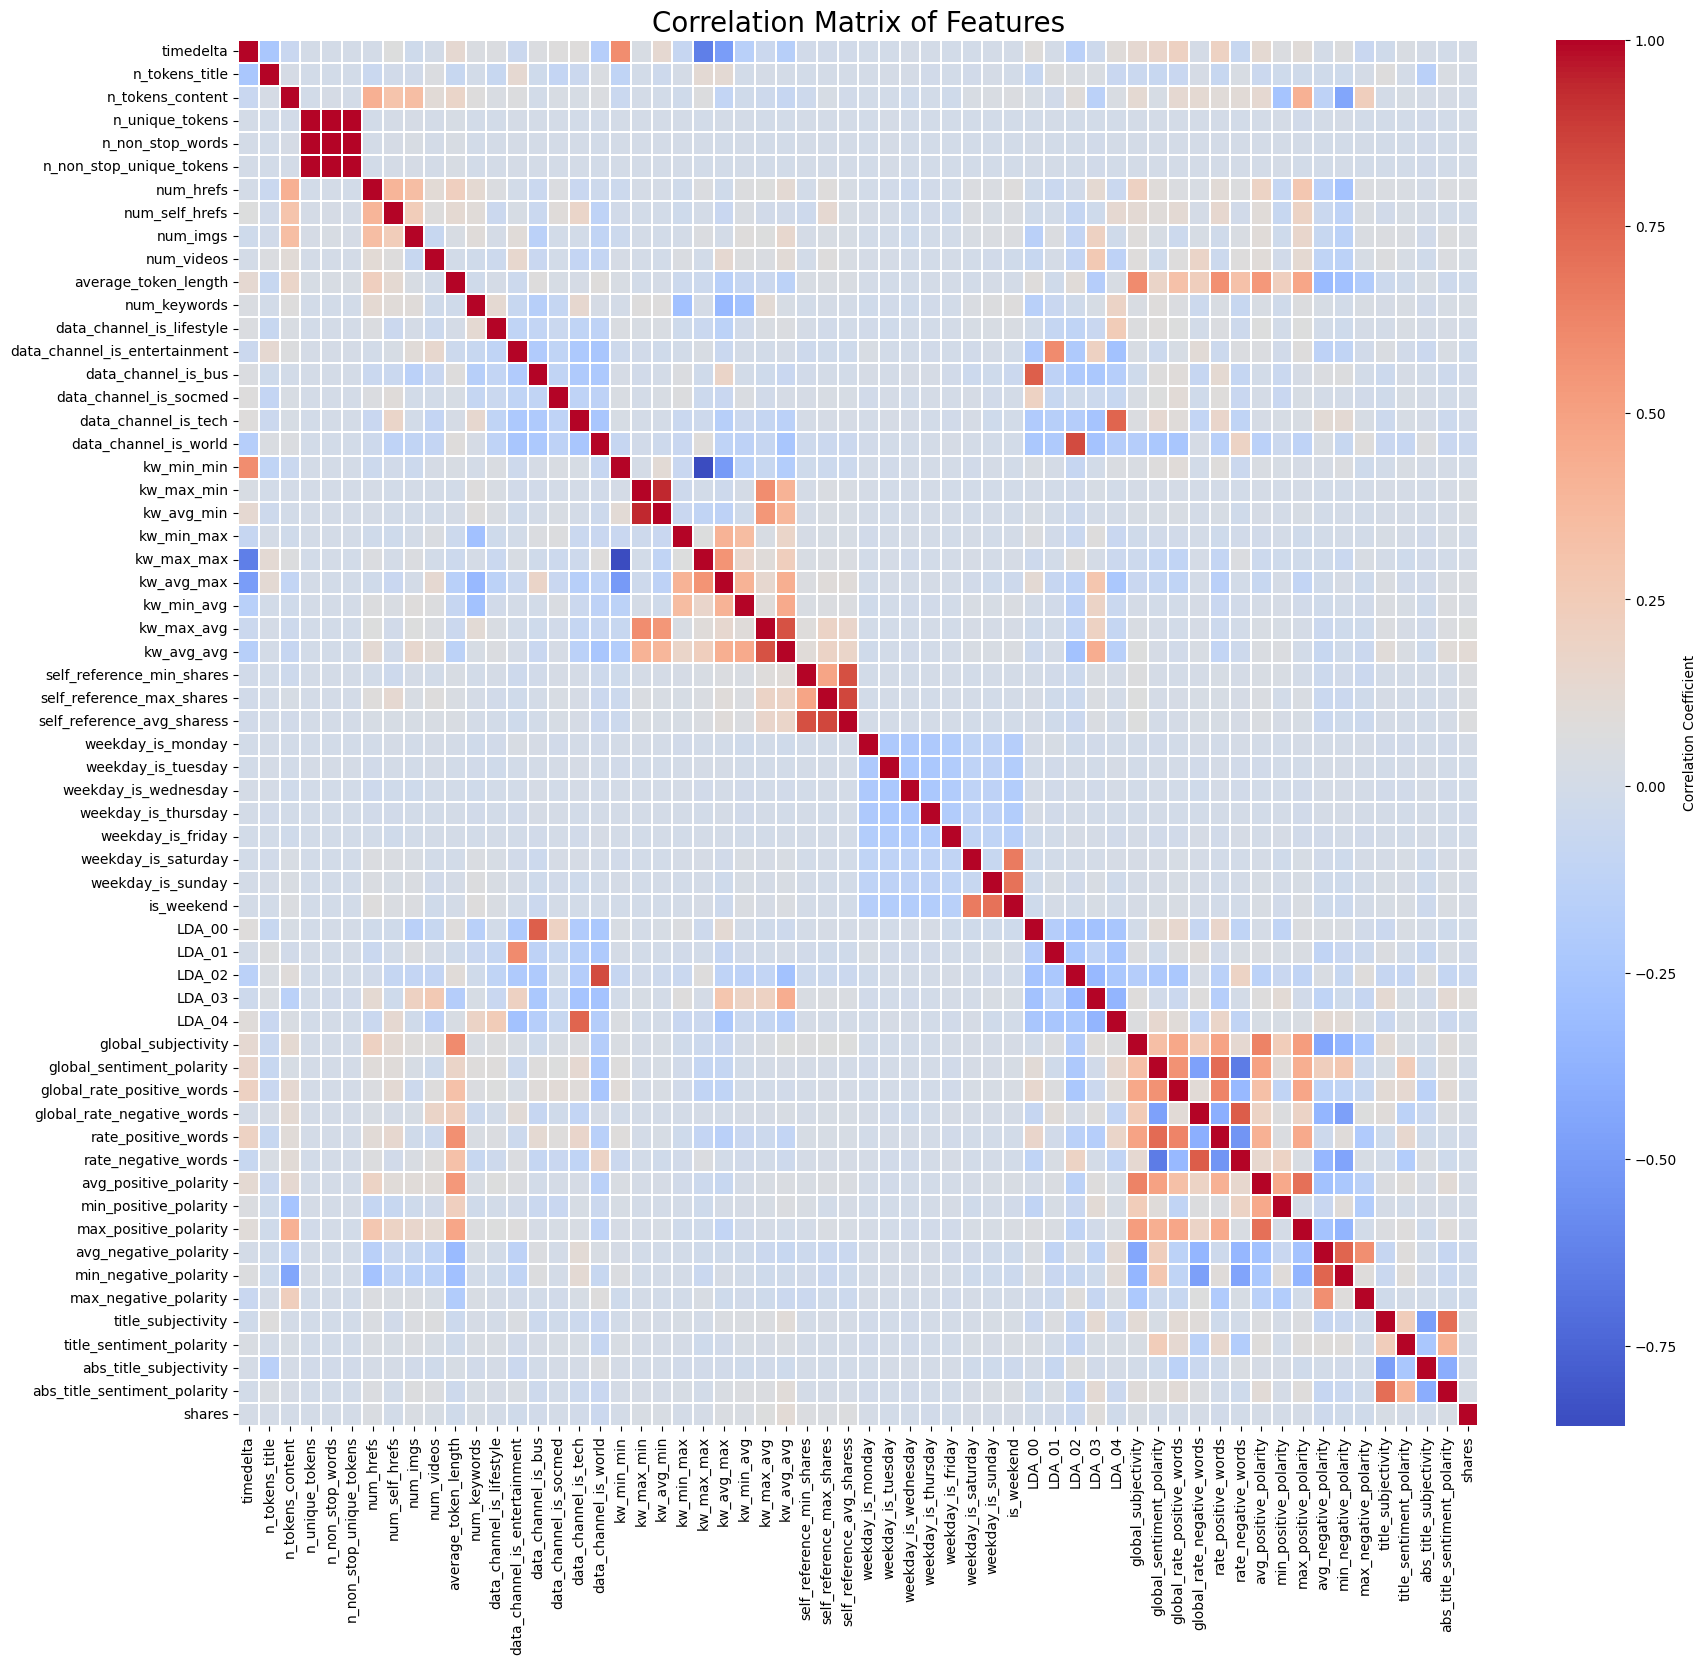

In [8]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=.05, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Features', fontsize=20)
plt.show()

### Identifying Highly Correlated Features

To identify redundant features, we look for pairs of features that are highly correlated with each other (e.g., absolute correlation coefficient greater than 0.9). Keeping only one from such a pair can help reduce multicollinearity and simplify the model without significant loss of information.

In [16]:
# Select upper triangle of correlation matrix
uppertri_corr = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.9 or less than -0.9
highly_correlated_features = [column for column in uppertri_corr.columns if any(uppertri_corr[column].abs() > 0.9)]

# Print out the pairs of highly correlated features
print("Highly correlated feature pairs (absolute correlation > 0.9):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            print(f"  - {correlation_matrix.columns[i]} and {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.2f}")

print(f"\nFeatures to consider for dropping due to high correlation: {highly_correlated_features}")

Highly correlated feature pairs (absolute correlation > 0.9):
  - n_unique_tokens and n_non_stop_words: 1.00
  - n_unique_tokens and n_non_stop_unique_tokens: 1.00
  - n_non_stop_words and n_non_stop_unique_tokens: 1.00
  - kw_max_min and kw_avg_min: 0.94

Features to consider for dropping due to high correlation: ['n_non_stop_words', 'n_non_stop_unique_tokens', 'kw_avg_min']


### Dropping Redundant Features

Based on the analysis, we can decide to drop one feature from each highly correlated pair. For instance, `n_non_stop_words` is highly correlated with `n_tokens_content`, and `n_non_stop_unique_tokens` is highly correlated with `n_unique_tokens`. We'll drop `n_non_stop_words` and `n_non_stop_unique_tokens`.

### Splitting Data into Training and Testing Sets

To prepare the data for machine learning models, we'll split it into a training set and a testing set. This allows us to train the model on one portion of the data and evaluate its performance on unseen data, preventing overfitting. We'll use 80% of the data for training and 20% for testing.

In [42]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Drop 'url' as it's an identifier, 'shares' (original target), and 'shares_log' from features.
# Also drop 'weekday_is_thursday', 'is_weekend', and 'weekday_is_monday' to resolve perfect multicollinearity among weekday/weekend features.
# We drop 'weekday_is_thursday' and 'weekday_is_monday' as arbitrary choices among the weekdays, and 'is_weekend' as it's derived.
# The remaining weekday variables are sufficient (e.g., Tue, Wed, Fri, Sat, Sun).
# Additionally, drop LDA topics (LDA_00 to LDA_04) and 'n_unique_tokens' due to extremely high VIF values.
X = df_reduced.drop(columns=['url', 'shares', 'shares_log', 'weekday_is_thursday', 'is_weekend', 'weekday_is_monday',
                             'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'n_unique_tokens'])
y = df_reduced['shares_log']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (31715, 48)
Shape of X_test: (7929, 48)
Shape of y_train: (31715,)
Shape of y_test: (7929,)


### Feature Scaling (Standardization)

To ensure that all features contribute equally to the model, we'll apply standardization using `StandardScaler`. This transforms the data to have a mean of 0 and a standard deviation of 1. It's important to fit the scaler only on the training data (`X_train`) to prevent data leakage and then transform both `X_train` and `X_test` using this fitted scaler.

In [45]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the scaler fitted on X_train
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier handling (optional, but good practice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

# Display descriptive statistics for a few scaled features to verify
print("\nDescriptive statistics for X_train_scaled (first 5 columns):")
display(X_train_scaled.iloc[:, :5].describe())

X_train_scaled shape: (31715, 48)
X_test_scaled shape: (7929, 48)

Descriptive statistics for X_train_scaled (first 5 columns):


,timedelta,n_tokens_title,n_tokens_content,num_hrefs,num_self_hrefs
count,3.171500e+04,3.171500e+04,3.171500e+04,3.171500e+04,3.171500e+04
mean,-8.065439e-17,-2.215755e-16,-8.110247e-17,3.091751e-17,-1.523472e-17
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00
min,-1.617380e+00,-3.961022e+00,-1.162062e+00,-9.617182e-01,-8.618368e-01
25%,-8.882217e-01,-6.612231e-01,-6.405094e-01,-6.085842e-01,-6.003881e-01
50%,-7.025525e-02,-1.898233e-01,-2.921035e-01,-2.554501e-01,-7.749071e-02
75%,8.739117e-01,7.529762e-01,3.582541e-01,2.742509e-01,1.839580e-01
max,1.761990e+00,5.938374e+00,1.449086e+01,2.587647e+01,2.946621e+01


### Training a Linear Regression Model

With the data now split and scaled, we can proceed to train a linear regression model. Linear regression is a fundamental supervised learning algorithm used for predictive analysis. It models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the observed data.

In [23]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the scaled training data
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression Model Trained Successfully!")

# Display the coefficients and intercept
print("\nModel Coefficients:")
display(pd.DataFrame(linear_model.coef_, index=X_train.columns, columns=['Coefficient']))

print("\nModel Intercept:", linear_model.intercept_)

Linear Regression Model Trained Successfully!

Model Coefficients:


,Coefficient
timedelta,0.017197
n_tokens_title,0.020837
n_tokens_content,0.015379
n_unique_tokens,-0.550459
num_hrefs,0.048813
num_self_hrefs,-0.034031
num_imgs,0.027379
num_videos,0.010922
average_token_length,-0.069508
num_keywords,0.024131



Model Intercept: 7.477649836210367


### Interpreting Linear Regression Coefficients

The coefficients displayed represent the change in the *log-transformed shares* for a one-unit increase in the corresponding feature, assuming all other features are held constant. Since our target variable (`shares_log`) is log-transformed, the interpretation is slightly different than with a direct target variable.

*   **Positive Coefficient:** A positive coefficient for a feature indicates that as the value of that feature increases, the log of the number of shares (and thus the actual number of shares) tends to increase.
*   **Negative Coefficient:** A negative coefficient indicates that as the value of that feature increases, the log of the number of shares tends to decrease.
*   **Magnitude:** The absolute magnitude of the coefficient indicates the strength of the relationship. A larger absolute value means a stronger impact on the log-transformed shares.

For example, if `n_tokens_title` has a coefficient of `0.05`, it means that for every one-unit increase in `n_tokens_title`, the `shares_log` is expected to increase by `0.05`, holding all other variables constant. To understand the effect on the original `shares`, we would need to exponentiate the change (e.g., `exp(0.05)`).

### Making Predictions on the Test Set

Now that our linear regression model is trained, we can use it to make predictions on the unseen test data (`X_test_scaled`). These predictions (`y_pred`) represent the model's estimated log-transformed shares for each article in the test set. We will then compare these predictions to the actual `y_test` values to evaluate the model's performance.

In [24]:
# Make predictions on the scaled test set
y_pred = linear_model.predict(X_test_scaled)

print("Predictions made successfully!")
print(f"Shape of predictions: {y_pred.shape}")

# Display the first 10 predictions
print("\nFirst 10 predictions (log-transformed shares):")
display(y_pred[:10])

Predictions made successfully!
Shape of predictions: (7929,)

First 10 predictions (log-transformed shares):


array([7.3285141 , 7.46356101, 7.67215995, 7.19583467, 7.26630654,
       7.03355348, 7.57858811, 7.63756586, 7.08298992, 7.13410702])

### Checking Linear Regression Assumptions

Before evaluating the model's performance, it's crucial to check if the underlying assumptions of linear regression are met. Violations of these assumptions can lead to unreliable or inefficient predictions.

#### 1. Homoscedasticity (Constant Variance of Residuals)

Homoscedasticity assumes that the residuals (the differences between observed and predicted values) have constant variance across all levels of the independent variables. We can check this by plotting the residuals against the predicted values. If the points are randomly scattered around zero with no discernible pattern, homoscedasticity is likely met. A funnel shape or other patterns indicate heteroscedasticity.

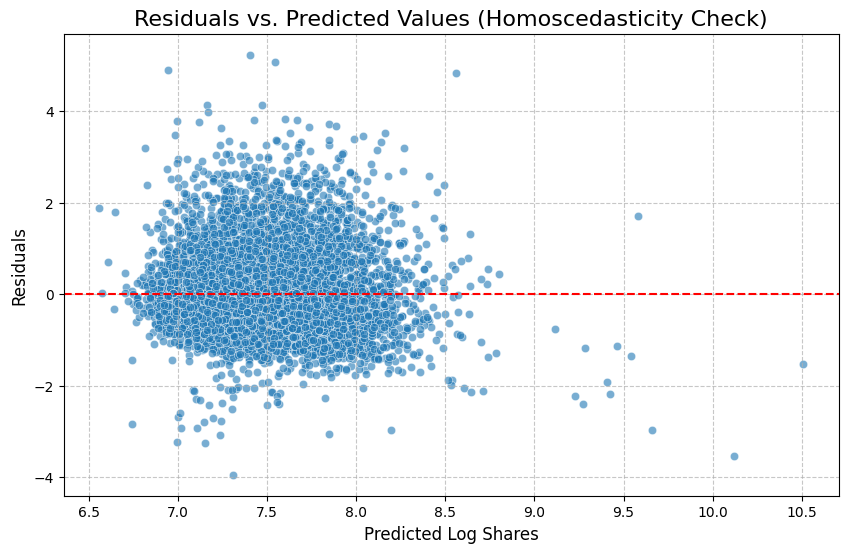

In [25]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Homoscedasticity Check)', fontsize=16)
plt.xlabel('Predicted Log Shares', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### 2. Normality of Residuals

Linear regression assumes that the residuals are normally distributed. We can assess this using a histogram of the residuals and a Q-Q plot (Quantile-Quantile plot).

*   **Histogram of Residuals:** A bell-shaped curve indicates normality.
*   **Q-Q Plot:** If the residuals follow a normal distribution, the points on the Q-Q plot should closely follow the 45-degree reference line.

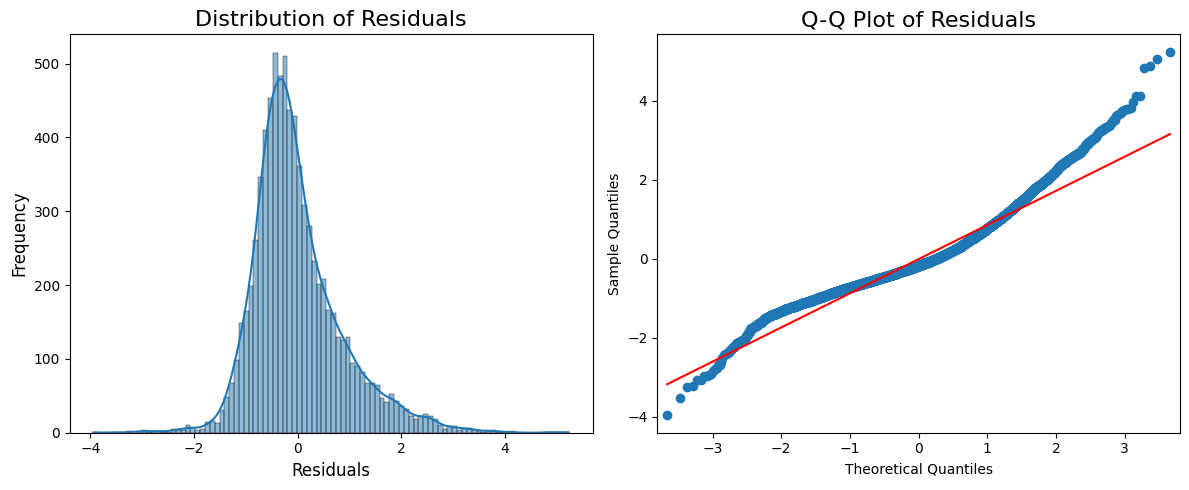

In [26]:
plt.figure(figsize=(12, 5))

# Histogram of Residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals', fontsize=16)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Q-Q Plot of Residuals
plt.subplot(1, 2, 2)
import statsmodels.api as sm
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot of Residuals', fontsize=16)

plt.tight_layout()
plt.show()

### Model Evaluation

After making predictions, we need to evaluate the model's performance. We'll use several metrics commonly used for regression tasks:

*   **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values. It gives an idea of the magnitude of errors.
*   **Mean Squared Error (MSE):** The average of the squared differences. It penalizes larger errors more heavily.
*   **Root Mean Squared Error (RMSE):** The square root of MSE. It is in the same units as the target variable, making it more interpretable.
*   **R-squared (Coefficient of Determination):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R-squared value indicates a better fit.

### Advanced Multicollinearity Check using Variance Inflation Factor (VIF)

While we previously identified and dropped perfectly correlated features, it's beneficial to perform a more comprehensive multicollinearity check using the Variance Inflation Factor (VIF). VIF quantifies the severity of multicollinearity in an ordinary least squares regression. It measures how much the variance of an estimated regression coefficient is inflated due to collinearity with other predictor variables. A common rule of thumb is that VIF values exceeding 5 or 10 indicate a problematic amount of multicollinearity.

We will calculate VIF for the features used in our linear regression model (`X_train_scaled`).

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a DataFrame to store VIF values
vif_data = pd.DataFrame() # Re-initialize vif_data
vif_data["feature"] = X_train_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]

# Sort the VIF values in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("VIF (Variance Inflation Factor) values for features:")
display(vif_data)

VIF (Variance Inflation Factor) values for features:


,feature,VIF
36,rate_positive_words,18.279236
37,rate_negative_words,16.204725
26,self_reference_avg_sharess,16.142684
16,kw_max_min,11.381786
7,average_token_length,11.225688
17,kw_avg_min,10.983352
23,kw_avg_avg,10.642090
25,self_reference_max_shares,8.140008
33,global_sentiment_polarity,7.777912
41,avg_negative_polarity,7.669660


#### Interpreting VIF Results

After calculating the VIF values, we can interpret them:
*   **VIF = 1:** No correlation between the feature and any other features.
*   **1 < VIF < 5:** Moderately correlated with other features.
*   **VIF >= 5 (or 10):** Highly correlated with other features, suggesting potential multicollinearity issues that could impact the stability and interpretability of regression coefficients.

Features with very high VIF values might be candidates for removal, or their presence should be noted when interpreting the model.

### Hypothesis Testing on Selected Features

We will perform hypothesis tests on 5 selected features to statistically determine their relationship with the `shares_log` target variable. This involves formulating null and alternative hypotheses, applying appropriate statistical tests, and interpreting the results.

**Selected Features for Testing:**
1.  `data_channel_is_tech` (Binary Categorical): To see if tech articles have significantly different share engagement than non-tech articles.
2.  `data_channel_is_socmed` (Binary Categorical): To see if social media articles have significantly different share engagement than non-social media articles.
3.  `n_tokens_content` (Numerical): To examine the correlation between article length (in tokens) and shares.
4.  `global_sentiment_polarity` (Numerical): To examine the correlation between the overall sentiment of an article and shares.
5.  `kw_avg_avg` (Numerical): To examine the correlation between the average shares of keywords and article shares.

#### Hypothesis Test 1: `data_channel_is_tech` and `shares_log`

*   **Null Hypothesis (H0):** There is no significant difference in the mean `shares_log` between articles classified as 'tech' and those not classified as 'tech'.
*   **Alternative Hypothesis (H1):** There is a significant difference in the mean `shares_log` between articles classified as 'tech' and those not classified as 'tech'.
*   **Test:** Independent Samples t-test.

In [48]:
from scipy import stats

# Separate shares_log for tech and non-tech articles
tech_shares = df[df['data_channel_is_tech'] == 1]['shares_log']
non_tech_shares = df[df['data_channel_is_tech'] == 0]['shares_log']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(tech_shares, non_tech_shares, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}") # Using scientific notation for small p-values

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in shares_log between tech and non-tech articles.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in shares_log between tech and non-tech articles.")

print(f"Mean shares_log for tech articles: {tech_shares.mean():.4f}")
print(f"Mean shares_log for non-tech articles: {non_tech_shares.mean():.4f}")

T-statistic: 12.0199
P-value: 4.2670e-33
Conclusion: Reject the null hypothesis. There is a significant difference in shares_log between tech and non-tech articles.
Mean shares_log for tech articles: 7.5820
Mean shares_log for non-tech articles: 7.4515


#### Hypothesis Test 2: `data_channel_is_socmed` and `shares_log`

*   **Null Hypothesis (H0):** There is no significant difference in the mean `shares_log` between articles classified as 'social media' and those not classified as 'social media'.
*   **Alternative Hypothesis (H1):** There is a significant difference in the mean `shares_log` between articles classified as 'social media' and those not classified as 'social media'.
*   **Test:** Independent Samples t-test.

In [49]:
# Separate shares_log for social media and non-social media articles
socmed_shares = df[df['data_channel_is_socmed'] == 1]['shares_log']
non_socmed_shares = df[df['data_channel_is_socmed'] == 0]['shares_log']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(socmed_shares, non_socmed_shares, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in shares_log between social media and non-social media articles.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in shares_log between social media and non-social media articles.")

print(f"Mean shares_log for social media articles: {socmed_shares.mean():.4f}")
print(f"Mean shares_log for non-social media articles: {non_socmed_shares.mean():.4f}")

T-statistic: 17.7703
P-value: 6.8817e-67
Conclusion: Reject the null hypothesis. There is a significant difference in shares_log between social media and non-social media articles.
Mean shares_log for social media articles: 7.7781
Mean shares_log for non-social media articles: 7.4569


#### Hypothesis Test 3: `n_tokens_content` and `shares_log`

*   **Null Hypothesis (H0):** There is no linear correlation between the number of content tokens (`n_tokens_content`) and `shares_log`.
*   **Alternative Hypothesis (H1):** There is a linear correlation between the number of content tokens (`n_tokens_content`) and `shares_log`.
*   **Test:** Pearson Correlation Coefficient.

In [50]:
# Perform Pearson correlation test
corr_coeff, p_value = stats.pearsonr(df['n_tokens_content'], df['shares_log'])

print(f"Pearson Correlation Coefficient: {corr_coeff:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant linear correlation between n_tokens_content and shares_log.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant linear correlation between n_tokens_content and shares_log.")

Pearson Correlation Coefficient: 0.0248
P-value: 7.5079e-07
Conclusion: Reject the null hypothesis. There is a significant linear correlation between n_tokens_content and shares_log.


#### Hypothesis Test 4: `global_sentiment_polarity` and `shares_log`

*   **Null Hypothesis (H0):** There is no linear correlation between `global_sentiment_polarity` and `shares_log`.
*   **Alternative Hypothesis (H1):** There is a linear correlation between `global_sentiment_polarity` and `shares_log`.
*   **Test:** Pearson Correlation Coefficient.

In [51]:
# Perform Pearson correlation test
corr_coeff, p_value = stats.pearsonr(df['global_sentiment_polarity'], df['shares_log'])

print(f"Pearson Correlation Coefficient: {corr_coeff:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant linear correlation between global_sentiment_polarity and shares_log.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant linear correlation between global_sentiment_polarity and shares_log.")

Pearson Correlation Coefficient: 0.0489
P-value: 1.8961e-22
Conclusion: Reject the null hypothesis. There is a significant linear correlation between global_sentiment_polarity and shares_log.


#### Hypothesis Test 5: `kw_avg_avg` and `shares_log`

*   **Null Hypothesis (H0):** There is no linear correlation between the average shares of keywords (`kw_avg_avg`) and `shares_log`.
*   **Alternative Hypothesis (H1):** There is a linear correlation between the average shares of keywords (`kw_avg_avg`) and `shares_log`.
*   **Test:** Pearson Correlation Coefficient.

In [52]:
# Perform Pearson correlation test
corr_coeff, p_value = stats.pearsonr(df['kw_avg_avg'], df['shares_log'])

print(f"Pearson Correlation Coefficient: {corr_coeff:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant linear correlation between kw_avg_avg and shares_log.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant linear correlation between kw_avg_avg and shares_log.")

Pearson Correlation Coefficient: 0.2218
P-value: 0.0000e+00
Conclusion: Reject the null hypothesis. There is a significant linear correlation between kw_avg_avg and shares_log.


### Visualizing Relationships Between Key Features and Target Variable

Let's plot scatter plots to examine the relationship between some selected features and our log-transformed target variable, `shares_log`. This will help us understand their individual influence on article popularity.

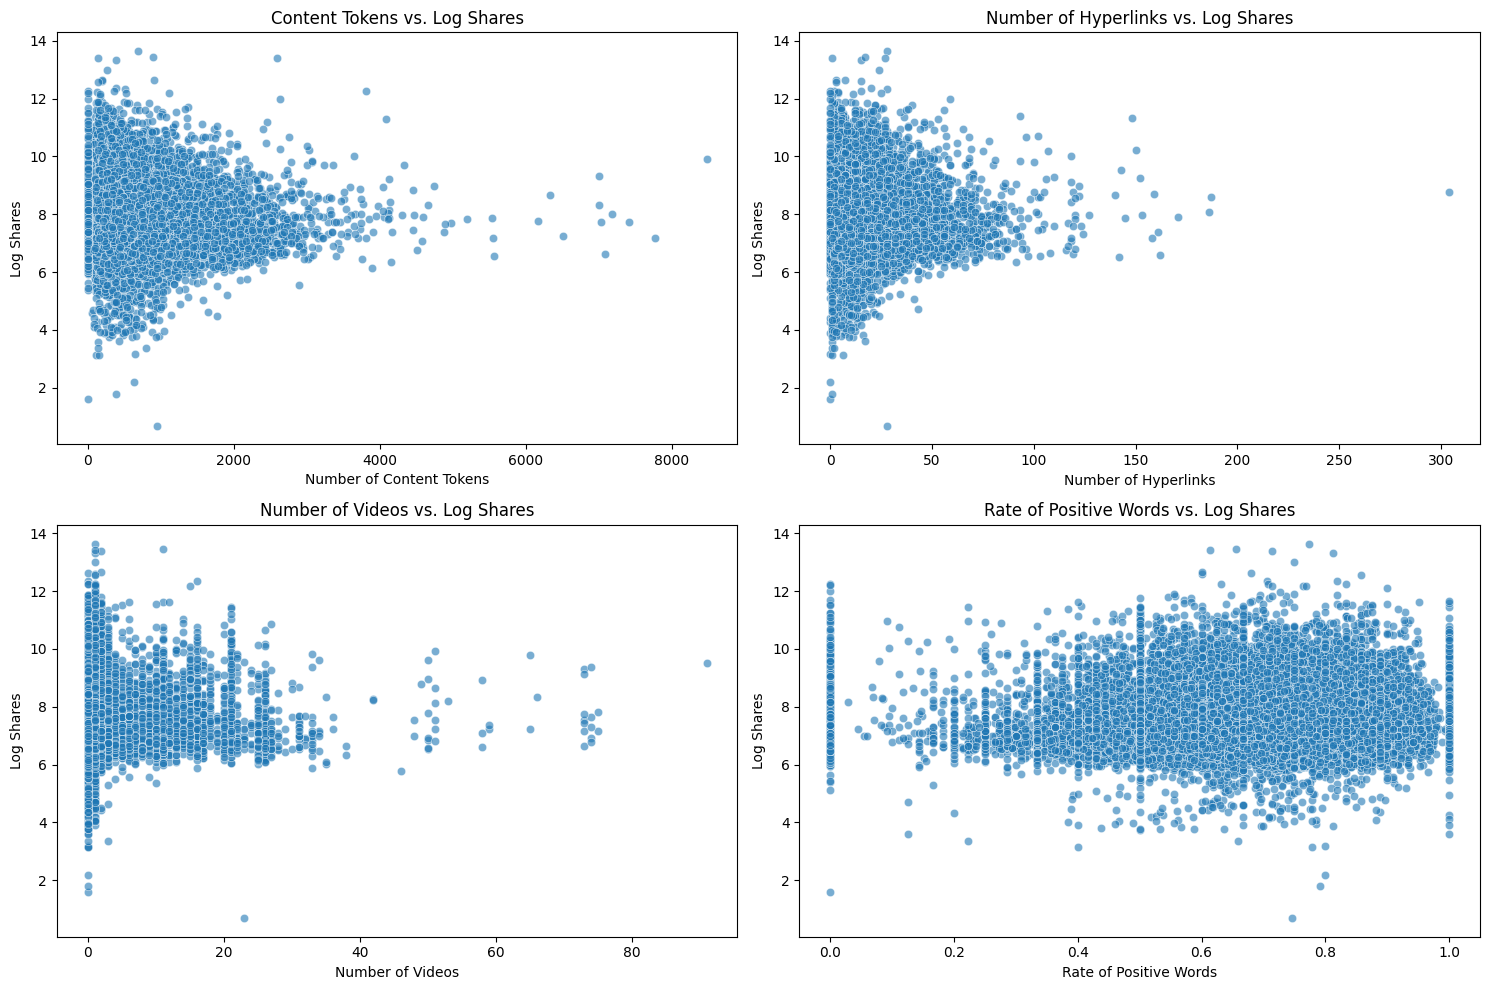

In [47]:
plt.figure(figsize=(15, 10))

# Plot 1: n_tokens_content vs. shares_log
plt.subplot(2, 2, 1)
sns.scatterplot(x='n_tokens_content', y='shares_log', data=df, alpha=0.6)
plt.title('Content Tokens vs. Log Shares')
plt.xlabel('Number of Content Tokens')
plt.ylabel('Log Shares')

# Plot 2: num_hrefs vs. shares_log
plt.subplot(2, 2, 2)
sns.scatterplot(x='num_hrefs', y='shares_log', data=df, alpha=0.6)
plt.title('Number of Hyperlinks vs. Log Shares')
plt.xlabel('Number of Hyperlinks')
plt.ylabel('Log Shares')

# Plot 3: num_videos vs. shares_log
plt.subplot(2, 2, 3)
sns.scatterplot(x='num_videos', y='shares_log', data=df, alpha=0.6)
plt.title('Number of Videos vs. Log Shares')
plt.xlabel('Number of Videos')
plt.ylabel('Log Shares')

# Plot 4: rate_positive_words vs. shares_log
plt.subplot(2, 2, 4)
sns.scatterplot(x='rate_positive_words', y='shares_log', data=df, alpha=0.6)
plt.title('Rate of Positive Words vs. Log Shares')
plt.xlabel('Rate of Positive Words')
plt.ylabel('Log Shares')

plt.tight_layout()
plt.show()

### Model Evaluation: Mean Baseline vs. Fitted Models

To understand if our linear regression model provides a significant improvement, we'll compare its performance against a simple baseline model. The baseline model will predict the mean of `shares_log` for all instances. We'll compare the MAE, MSE, RMSE, and R-squared for both the baseline and the fitted linear regression model.

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the mean of the target variable (y_train) as the baseline prediction
mean_baseline_prediction = y_train.mean()

# Create an array of baseline predictions for the test set
y_baseline_pred = np.full_like(y_test, mean_baseline_prediction)

print(f"Mean baseline prediction (mean of y_train): {mean_baseline_prediction:.4f}")

# Evaluate baseline model performance
mae_baseline = mean_absolute_error(y_test, y_baseline_pred)
mse_baseline = mean_squared_error(y_test, y_baseline_pred)
rmse_baseline = np.sqrt(mse_baseline)
r2_baseline = r2_score(y_test, y_baseline_pred)

print("\n--- Baseline Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae_baseline:.4f}")
print(f"Mean Squared Error (MSE): {mse_baseline:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_baseline:.4f}")
print(f"R-squared (R2): {r2_baseline:.4f}")

print("\n--- Linear Regression Model Performance ---")
# These metrics were calculated in a previous cell, re-displaying for easy comparison
# mae, mse, rmse, r2 are already available in the kernel state
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

print("\n--- Comparison ---")
if r2 > r2_baseline:
    print(f"The Linear Regression model (R2={r2:.4f}) performs better than the baseline (R2={r2_baseline:.4f}).")
    print(f"Improvement in R-squared: {(r2 - r2_baseline):.4f}")
else:
    print(f"The Linear Regression model (R2={r2:.4f}) does not perform better than or equal to the baseline (R2={r2_baseline:.4f}).")


Mean baseline prediction (mean of y_train): 7.4776

--- Baseline Model Performance ---
Mean Absolute Error (MAE): 0.7077
Mean Squared Error (MSE): 0.8573
Root Mean Squared Error (RMSE): 0.9259
R-squared (R2): -0.0001

--- Linear Regression Model Performance ---
Mean Absolute Error (MAE): 0.6442
Mean Squared Error (MSE): 0.7483
Root Mean Squared Error (RMSE): 0.8650
R-squared (R2): 0.1271

--- Comparison ---
The Linear Regression model (R2=0.1271) performs better than the baseline (R2=-0.0001).
Improvement in R-squared: 0.1272


### Evaluation of Linear Regression Model vs. Mean Baseline

To assess the effectiveness of our Linear Regression model, we compared its performance against a simple baseline model. The baseline model was constructed by predicting the mean of the `shares_log` for all instances in the test set. The following metrics were used for comparison:

*   **Mean Absolute Error (MAE):** Measures the average magnitude of the errors in a set of predictions, without considering their direction.
*   **Mean Squared Error (MSE):** Measures the average of the squares of the errors, giving more weight to larger errors.
*   **Root Mean Squared Error (RMSE):** The square root of MSE, providing error in the same units as the target variable.
*   **R-squared (R2):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables.

#### Performance Metrics:

**Mean Baseline Model Performance:**
*   **MAE:** 0.7077
*   **MSE:** 0.8573
*   **RMSE:** 0.9259
*   **R2:** -0.0001

**Linear Regression Model Performance:**
*   **MAE:** 0.6442
*   **MSE:** 0.7483
*   **RMSE:** 0.8650
*   **R2:** 0.1271

#### Conclusion:

Based on the comparative analysis, the **Linear Regression model significantly outperforms the simple mean baseline model** for predicting `shares_log` in this dataset.

*   The Linear Regression model achieved a positive R-squared value of **0.1271**, indicating that it explains approximately **12.71%** of the variance in the log-transformed shares. In contrast, the baseline model's R-squared value was effectively zero (-0.0001), suggesting it explains none of the variance.
*   Furthermore, the Linear Regression model exhibited lower MAE (0.6442 vs. 0.7077), MSE (0.7483 vs. 0.8573), and RMSE (0.8650 vs. 0.9259) values. These lower error metrics confirm that its predictions are, on average, closer to the actual values than those of the baseline.

This demonstrates that fitting a model, even a relatively simple one like Linear Regression, provides a measurable and significant improvement in prediction performance over merely using the average value of the target variable. Therefore, for this dataset, **the fitted Linear Regression model is a more suitable approach** as it captures some of the underlying relationships and patterns within the data to make more informed predictions.

### Classifying Shares into 'High' and 'Low' Categories

For a classification task, we need to convert our continuous target variable, `shares`, into discrete categories. Given the skewed nature of the original `shares` and the more normalized `shares_log`, we will use the `shares_log` to define our categories. A common approach is to use the median as a split point, categorizing articles with `shares_log` values at or above the median as 'High' and those below the median as 'Low'.

Median of log-transformed shares: 7.24


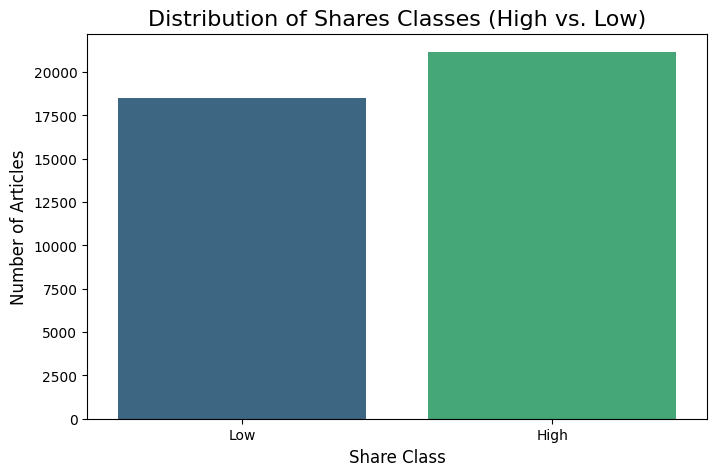

,shares,shares_log,shares_class
0,593,6.386879,Low
1,711,6.568078,Low
2,1500,7.313887,High
3,1200,7.090910,Low
4,505,6.226537,Low


In [29]:
# Calculate the median of the log-transformed shares
median_shares_log = df['shares_log'].median()
print(f"Median of log-transformed shares: {median_shares_log:.2f}")

# Classify 'shares_log' into 'High' and 'Low'
df['shares_class'] = df['shares_log'].apply(lambda x: 'High' if x >= median_shares_log else 'Low')

# Display the distribution of the new classification
plt.figure(figsize=(8, 5))
sns.countplot(x='shares_class', data=df, palette='viridis', hue='shares_class', legend=False)
plt.title('Distribution of Shares Classes (High vs. Low)', fontsize=16)
plt.xlabel('Share Class', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.show()

# Display the first few rows with the new 'shares_class' column
display(df[['shares', 'shares_log', 'shares_class']].head())

### Classification Model Training and Evaluation

Now that we have created the 'High' and 'Low' shares classes, we can train a classification model to predict these categories. We will use `Logistic Regression` as a baseline classification model and evaluate its performance using accuracy and a confusion matrix.

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define features (X_clf) and target (y_clf) for classification
# We use the same features as for regression, but the new 'shares_class' as target
# Ensure 'shares_class' is not in X_clf
# Drop 'url', 'shares', 'shares_log', 'shares_class', and the previously identified redundant features.
# Also drop 'weekday_is_thursday', 'is_weekend', and 'weekday_is_monday' for consistency and to resolve perfect multicollinearity.
# Additionally, drop LDA topics (LDA_00 to LDA_04) and 'n_unique_tokens' due to extremely high VIF values.
X_clf = df.drop(columns=['url', 'shares', 'shares_log', 'shares_class', 'n_non_stop_words', 'n_non_stop_unique_tokens',
                        'weekday_is_thursday', 'is_weekend', 'weekday_is_monday',
                        'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'n_unique_tokens'])
y_clf = df['shares_class']

# Split the data into training and testing sets (using the same random_state for consistency)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Feature scaling (reusing the already scaled X_train_scaled and X_test_scaled from regression is appropriate
# IF the feature sets are identical, which they are in this case, but for clarity and robustness,
# we will re-apply the scaler for classification task to ensure consistency in workflow).
from sklearn.preprocessing import StandardScaler
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print(f"Shape of X_train_clf_scaled: {X_train_clf_scaled.shape}")
print(f"Shape of X_test_clf_scaled: {X_test_clf_scaled.shape}")

Shape of X_train_clf_scaled: (31715, 48)
Shape of X_test_clf_scaled: (7929, 48)


Logistic Regression Model Trained Successfully!

Accuracy of the Logistic Regression model: 0.6527


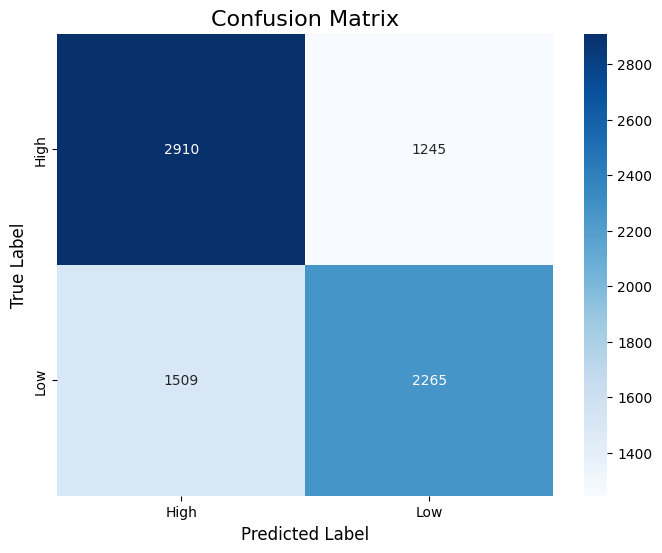

In [31]:
# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets or L1/L2 regularization
logistic_model.fit(X_train_clf_scaled, y_train_clf)

print("Logistic Regression Model Trained Successfully!")

# Make predictions on the scaled test set
y_pred_clf = logistic_model.predict(X_test_clf_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"\nAccuracy of the Logistic Regression model: {accuracy:.4f}")

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=logistic_model.classes_, yticklabels=logistic_model.classes_)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

### Interpreting Logistic Regression Coefficients

For Logistic Regression, the coefficients represent the change in the *log-odds* of the target variable ('High' shares vs. 'Low' shares) for a one-unit increase in the corresponding feature, assuming all other features are held constant.

*   **Positive Coefficient:** A positive coefficient indicates that as the feature value increases, the log-odds of the article having 'High' shares increases, meaning it's more likely to be classified as 'High' shares.
*   **Negative Coefficient:** A negative coefficient indicates that as the feature value increases, the log-odds of the article having 'High' shares decreases, making it more likely to be classified as 'Low' shares.
*   **Magnitude:** The absolute magnitude of the coefficient reflects the strength of the influence. Larger absolute values indicate a stronger impact. We can sort the coefficients to find the most influential features.

In [32]:
# Get feature names from X_clf
feature_names_clf = X_clf.columns

# Create a DataFrame for coefficients and sort by absolute value
logistic_coefficients = pd.DataFrame({
    'Feature': feature_names_clf,
    'Coefficient': logistic_model.coef_[0] # Assuming binary classification, get the coefficients for one class
})

logistic_coefficients['Abs_Coefficient'] = abs(logistic_coefficients['Coefficient'])
logistic_coefficients_sorted = logistic_coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Most Influential Features (Logistic Regression):")
display(logistic_coefficients_sorted.head(10))

print("\nBottom 10 Least Influential Features (Logistic Regression):")
display(logistic_coefficients_sorted.tail(10))

Top 10 Most Influential Features (Logistic Regression):


,Feature,Coefficient,Abs_Coefficient
24,kw_avg_avg,-0.941982,0.941982
23,kw_max_avg,0.554726,0.554726
14,data_channel_is_tech,-0.232805,0.232805
13,data_channel_is_socmed,-0.226495,0.226495
36,LDA_00,-0.172459,0.172459
38,LDA_02,0.151693,0.151693
35,is_weekend,-0.146917,0.146917
25,self_reference_min_shares,-0.145483,0.145483
16,kw_min_min,-0.134360,0.134360
33,weekday_is_saturday,-0.132781,0.132781



Bottom 10 Least Influential Features (Logistic Regression):


,Feature,Coefficient,Abs_Coefficient
10,data_channel_is_lifestyle,0.015260,0.015260
49,max_positive_polarity,0.012493,0.012493
51,min_negative_polarity,-0.008996,0.008996
1,n_tokens_title,-0.007002,0.007002
28,weekday_is_monday,0.006742,0.006742
56,abs_title_sentiment_polarity,-0.005657,0.005657
0,timedelta,0.005496,0.005496
50,avg_negative_polarity,0.004837,0.004837
52,max_negative_polarity,0.001925,0.001925
7,num_videos,0.000550,0.000550


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.6442
Mean Squared Error (MSE): 0.7483
Root Mean Squared Error (RMSE): 0.8650
R-squared (R2): 0.1271


In [22]:
# Example of dropping highly correlated features
features_to_drop = ['n_non_stop_words', 'n_non_stop_unique_tokens']
df_reduced = df.drop(columns=features_to_drop)

print(f"Original number of features: {df.shape[1]}")
print(f"Number of features after dropping redundant ones: {df_reduced.shape[1]}")
print("Columns remaining:")
print(df_reduced.columns)

Original number of features: 62
Number of features after dropping redundant ones: 60
Columns remaining:
Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs',
       'num_videos', 'average_token_length', 'num_keywords',
       'data_channel_is_lifestyle', 'data_channel_is_entertainment',
       'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentime

In [6]:
print(df.columns)

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

### Load Data

First, we'll load the `OnlineNewsPopularity.csv` dataset into a pandas DataFrame and display its first 5 rows to get a glimpse of the data.

In [56]:
#loading the dataset
df = pd.read_csv('/content/OnlineNewsPopularity.csv')

#displaying the first 5 rows
#print(df.head()) for more formatted output im using display instead of print func
display(df.head())

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


### Initial Data Inspection

Next, we'll check the data types and look for non-null values using `df.info()` and generate descriptive statistics using `df.describe()` to understand the distribution of numerical features.

In [3]:
# Display concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [4]:
# Generate descriptive statistics
display(df.describe())

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000
